# **Deliverable 4: MRI Physics & Imaging**

---

## Overview

This deliverable covers key concepts from **Lectures 25–28** (Weeks 10–11) of the course. You will explore the complete physics foundation underlying Magnetic Resonance Imaging — from spin relaxation and tissue contrast through spatial encoding, pulse sequences, and advanced techniques.

Upon successful completion, you will be able to:
1. **Analyze** T1 and T2 relaxation dynamics and explain how TR and TE determine image contrast.
2. **Design** MRI spatial encoding schemes using gradient fields and describe k-space filling strategies.
3. **Compare** gradient echo, spin echo, fast spin echo, and inversion recovery pulse sequences.
4. **Implement** MRI image reconstruction from k-space data using the Fourier transform.
5. **Evaluate** diffusion-weighted imaging for clinical applications (e.g., acute stroke detection).
6. **Identify and mitigate** common MRI artifacts and explain MRI safety hazards.

---

# Part 1: Relaxation, Contrast, and Timing Parameters

## Key Concepts

**T1 Relaxation (Spin-Lattice):** Recovery of longitudinal magnetization after RF excitation
- For a 90° pulse: $M_z(t)=M_0\left(1-e^{-t/T_1}\right)$
- At $t=T_1$: about 63% recovery
- Short-T1 tissues (e.g., fat) recover faster and appear brighter on T1-weighted images

**T2 and T2* Relaxation:** Decay of transverse magnetization due to dephasing
- $M_{xy}(t)=M_{xy}(0)e^{-t/T_2}$
- $\frac{1}{T_2^*}=\frac{1}{T_2}+\frac{1}{T_2'}$
- T2* includes field inhomogeneity effects, so $T_2^* < T_2$

**Contrast Control via TR and TE:**
- Short TR + short TE → T1-weighted
- Long TR + long TE → T2-weighted
- Long TR + short TE → PD-weighted
- Avoid short TR + long TE (mixed/poor contrast)

**Contrast Agents:**
- Gadolinium shortens T1 and increases signal on T1-weighted imaging
- Enhancement helps identify vascularity, permeability, and blood-brain barrier disruption

## 1.1 Relaxation Physics and Tissue Contrast

### **Questions 1**
You are comparing two tissues in a 1.5 T MRI scan:
Tissue A: $T_1 = 600$ ms, $T_2 = 80$ ms and Tissue B: $T_1 = 1200$ ms, $T_2 = 100$ ms

- a) For a 90° pulse, compute $M_z/M_0$ at $t = 300$ ms and $600$ ms for both tissues.
- b) A short-TR sequence is used. Which tissue will appear brighter on T1-weighted imaging, and how do your values support that answer?
- c) At $TE = 80$ ms, compare transverse signal fractions $e^{-TE/T_2}$ for both tissues. Based on your calculations, would these tissues separate more strongly on T1-weighted or T2-weighted imaging?

### **Answers for Questions 1**

- a) For Tissue A (T1=600): At t=300 ms, Mz/M0 = 1 - e^(-300/600) = 0.3935. At t=600 ms, Mz/M0 = 1 - e^(-600/600) = 0.6321

For Tissue B (T1=1200): At t=300 ms, Mz/M0 = 1 - e^(-300/1200) = 0.2212. At t=600 ms, Mz/M0 = 1 - e^(-600/1200) = 0.3935

- b) Tissue A will appear brighter. A short TR highlights T1 differences. Because Tissue A has a shorter T1 (600 ms), it recovers its longitudinal magnetization faster. As calculated, Tissue A has a higher signal fraction (0.393) than Tissue B (0.221) at 300 ms.

- c) Transverse signal = e^(-TE/T2). Tissue A: e^(-80/80) = 0.368. Tissue B: e^(-80/100) = 0.449. The T2 signal difference is small (0.081). However, the T1 signal difference at 600 ms is large (0.239). Therefore, T1-weighted imaging separates these tissues more strongly.

---------------------------------------

### **Questions 2**
A brain MRI includes CSF, white matter, and fat. Assume approximate values:

CSF: $T_1 = 4000$ ms, $T_2 = 2000$ ms, White matter: $T_1 = 600$ ms, $T_2 = 80$ ms, Fat: $T_1 = 250$ ms, $T_2 = 80$ ms

- a) Rank expected brightness for T1-weighted, T2-weighted, and PD-weighted imaging.
- b) Justify each ranking using the ideas of longitudinal recovery and transverse decay rather than memorization.
- c) A student suggests using short TR + long TE to maximize contrast. Critique this choice and explain what kind of mixed contrast it produces.

### **Answers for Questions 2**
- a) T1-weighted (brightest to darkest): Fat, White matter, CSF.

T2-weighted: CSF, White matter = Fat.

PD-weighted: CSF, Fat, White matter (based on true hydrogen density).

- b) T1W uses short TR; fat recovers longitudinal magnetization fastest (shortest T1), yielding the highest signal. T2W uses long TE; CSF's transverse magnetization decays slowest (longest T2), remaining bright while others decay. PDW uses long TR (full longitudinal recovery) and short TE (minimal transverse decay); signal strictly reflects hydrogen proton concentration.

- c) This is not a good choice. Short TR lowers signal for tissues with long T1. Long TE lowers signal for tissues with short T2. This creates conflicting mixed contrast where all tissue signals are heavily penalized, resulting in an image with poor overall signal and no useful contrast.
-----------------

## 1.2 Relaxation Curve and Contrast Simulation

### **Coding Exercise 1**
Implement a simulation that compares longitudinal and transverse magnetization behavior across tissues.

Tasks:
1. Define tissue parameters (e.g., CSF, white matter, fat): $T_1$, $T_2$.
2. Plot $M_z(t)=M_0\left(1-e^{-t/T_1}\right)$ over time after a 90° pulse.
3. Plot $M_{xy}(t)=M_{xy}(0)e^{-t/T_2}$ over time.
4. Simulate signal intensity under different $(TR,TE)$ choices:
   - T1-weighted: short TR / short TE
   - T2-weighted: long TR / long TE
   - PD-weighted: long TR / short TE
5. Summarize which tissue is brightest under each weighting and why.

**Helpful Note:** You may use the tissue values from **Questions 2** directly (CSF, white matter, fat). To review equations and interpretation, look back at **Lecture 25** (relaxation + TR/TE weighting) and the Part 1 key concepts above.

=== Coding Exercise 1: Relaxation and Contrast Simulation ===


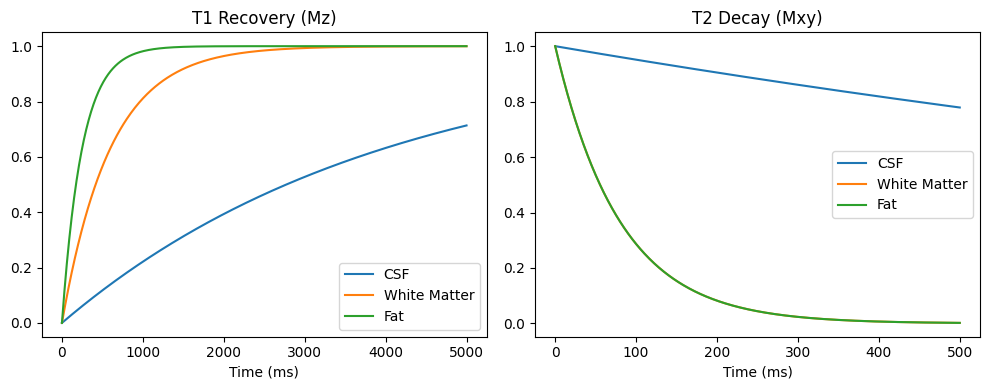

--- T1W Weighting ---
Fat: 0.717
White Matter: 0.469
CSF: 0.117
Rank (Brightest to Darkest): Fat > White Matter > CSF

--- T2W Weighting ---
CSF: 0.502
Fat: 0.287
White Matter: 0.285
Rank (Brightest to Darkest): CSF > Fat > White Matter

--- PDW Weighting ---
Fat: 0.829
White Matter: 0.823
CSF: 0.524
Rank (Brightest to Darkest): Fat > White Matter > CSF



In [1]:
print("=== Coding Exercise 1: Relaxation and Contrast Simulation ===")

import matplotlib.pyplot as plt
import numpy as np

M0 = 1.0

def mz_recovery(time_ms, t1_ms, m0=1.0):
    return m0 * (1 - np.exp(-time_ms / t1_ms))


def mxy_decay(time_ms, t2_ms, mxy0=1.0):
    return mxy0 * np.exp(-time_ms / t2_ms)


def spin_echo_signal(tr_ms, te_ms, t1_ms, t2_ms):
    return (1 - np.exp(-tr_ms / t1_ms)) * np.exp(-te_ms / t2_ms)


# TODO 1: Define the tissue dictionary.
tissues = {
    'CSF': {'T1': 4000, 'T2': 2000},
    'White Matter': {'T1': 600, 'T2': 80},
    'Fat': {'T1': 250, 'T2': 80}
}

# TODO 2: Create time axes for T1 recovery and T2 decay.
t_rec = np.linspace(0, 5000, 500)
t_dec = np.linspace(0, 500, 500)

# TODO 3: Compute Mz(t) and Mxy(t) for each tissue.
mz = {name: mz_recovery(t_rec, p['T1']) for name, p in tissues.items()}
mxy = {name: mxy_decay(t_dec, p['T2']) for name, p in tissues.items()}

# TODO 4: Plot the T1 recovery and T2 decay curves.
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
for name, val in mz.items(): plt.plot(t_rec, val, label=name)
plt.title('T1 Recovery (Mz)'), plt.xlabel('Time (ms)'), plt.legend()

plt.subplot(1, 2, 2)
for name, val in mxy.items(): plt.plot(t_dec, val, label=name)
plt.title('T2 Decay (Mxy)'), plt.xlabel('Time (ms)'), plt.legend()
plt.tight_layout()
plt.show()

# TODO 5: Define T1-, T2-, and PD-weighted (TR, TE) settings.
protocols = {
    'T1W': {'TR': 500, 'TE': 15},
    'T2W': {'TR': 3000, 'TE': 100},
    'PDW': {'TR': 3000, 'TE': 15}
}

# TODO 6: Compute the signal for each tissue under each weighting.
signals = {}
for w, p in protocols.items():
    signals[w] = {name: spin_echo_signal(p['TR'], p['TE'], t['T1'], t['T2']) 
                  for name, t in tissues.items()}

# TODO 7: Summarize the brightness ranking for each weighting.
for w, sigs in signals.items():
    ranked = sorted(sigs, key=sigs.get, reverse=True)
    print(f"--- {w} Weighting ---")
    for name in ranked:
        print(f"{name}: {sigs[name]:.3f}")
    print(f"Rank (Brightest to Darkest): {' > '.join(ranked)}\n")
# ...

## 1.3 Contrast Agent and Field-Strength Analysis

### **Questions 3**
A lesion has pre-contrast $T_{1,0}=1000$ ms. After gadolinium injection, assume
$R_1=1/T_1 = 1/T_{1,0} + r_1[C]$, with $r_1 = 4\ \mathrm{L\,mmol^{-1}\,s^{-1}}$ and $[C]=0.2\ \mathrm{mmol/L}$.

- a) Compute post-contrast $T_1$ and predict how the lesion signal changes on a T1-weighted image.
- b) Explain why lesion enhancement often suggests blood-brain barrier disruption, and name one intracranial structure that enhances normally.
- c) Why must renal function be checked before gadolinium is given?

### **Answers for Question 3**

- a) Pre-contrast T1 is 1000 ms (1 s). R1 = 1/1 + (4 * 0.2) = 1.8. Post-contrast T1 = 1 / 1.8 = 0.556 s (556 ms). Gadolinium shortens T1. Therefore, the lesion will appear brighter on a T1-weighted image.
- b) Gadolinium is an extracellular agent that cannot cross a healthy blood-brain barrier (BBB). Enhancement means the agent leaked into tissue, indicating BBB breakdown. 
- c) Gadolinium is excreted by the kidneys. In patients with renal failure, there is a risk of developing Nephrogenic Systemic Fibrosis (NSF). Therefore, you must check the Glomerular Filtration Rate (GFR) before administration.
----------------------
### **Questions 4**
At 3 T, many tissues show longer T1 values than at 1.5 T.

- a) Explain why a T1-weighted protocol copied directly from 1.5 T may not preserve the same contrast at 3 T.
- b) If you could change only one parameter first, would you adjust TR or flip angle? Defend your answer.
- c) Give one important benefit and one important drawback of moving from 1.5 T to 3 T for routine MRI.

### **Answers for Question 4**
- a) T1 relaxation time increases with higher magnetic field strength (B0). A protocol optimized for 1.5 T uses a specific TR. At 3 T, tissues have longer T1s and need more time to recover. The old TR will cause poor contrast.
- b) You should adjust TR. TR directly controls T1 weighting. Since T1 times are longer at 3 T, you must increase the TR to allow sufficient longitudinal magnetization recovery and maintain the desired tissue contrast.
- c) Benefit: Higher B0 creates more net magnetization, resulting in a higher Signal-to-Noise Ratio (SNR).
Drawback: Specific Absorption Rate (SAR) increases proportional to the square of B0, leading to greater tissue heating risk
---------------------------------------------

## 1.4 Contrast Agent and Field-Strength Simulation

### **Coding Exercise 2**
Build a compact simulation to study contrast-agent and field-strength effects.

Tasks:
1. Implement $\frac{1}{T_1}=\frac{1}{T_{1,0}}+r_1[C]$ and compute post-contrast $T_1$ for multiple concentrations.
2. Compare expected T1-weighted signal at 1.5 T and 3 T across a TR sweep.
3. Identify TR ranges that preserve lesion-to-background contrast.

**Helpful Note:** You can start from the values already given in **Question 3**, or choose your own reasonable values and state assumptions.

=== Coding Exercise 2: Contrast Agent and Field-Strength Simulation ===


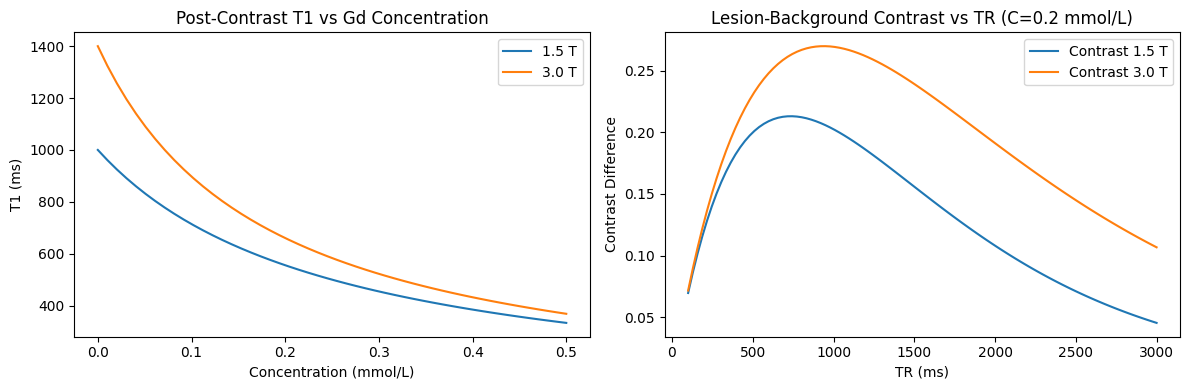

Note: At 3 T, SAR (tissue heating) increases proportional to B0^2.
It is 4 times higher than at 1.5 T, requiring strict parameter limits.


In [2]:
print("=== Coding Exercise 2: Contrast Agent and Field-Strength Simulation ===")

import matplotlib.pyplot as plt
import numpy as np

r1 = 4.0  # L mmol^-1 s^-1

def post_contrast_t1(t1_pre_ms, concentration_mmol_per_l, relaxivity=r1):
    t1_pre_s = t1_pre_ms / 1000.0
    r1_pre = 1.0 / t1_pre_s
    r1_post = r1_pre + relaxivity * concentration_mmol_per_l
    return 1000.0 / r1_post


def t1_weighted_signal(tr_ms, t1_ms):
    return 1 - np.exp(-tr_ms / t1_ms)


# TODO 1: Define baseline T1 values at 1.5 T and 3 T.
t1_bg_15t = 1000.0
t1_lesion_pre_15t = 1000.0

t1_bg_3t = 1400.0
t1_lesion_pre_3t = 1400.0

# TODO 2: Create a gadolinium concentration array.
c_array = np.linspace(0, 0.5, 50)

# TODO 3: Compute post-contrast lesion T1 for each field strength.
t1_post_15t = post_contrast_t1(t1_lesion_pre_15t, c_array)
t1_post_3t = post_contrast_t1(t1_lesion_pre_3t, c_array)

# TODO 4: Plot post-contrast lesion T1 versus concentration.
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(c_array, t1_post_15t, label="1.5 T")
plt.plot(c_array, t1_post_3t, label="3.0 T")
plt.title("Post-Contrast T1 vs Gd Concentration")
plt.xlabel("Concentration (mmol/L)")
plt.ylabel("T1 (ms)")
plt.legend()

# TODO 5: Create a TR sweep.
tr_sweep = np.linspace(100, 3000, 100)
c_fixed = 0.2 # Based on Question 3

# TODO 6: Compute T1-weighted signal for lesion and background.
lesion_t1_15t_fixed = post_contrast_t1(t1_lesion_pre_15t, c_fixed)
lesion_t1_3t_fixed = post_contrast_t1(t1_lesion_pre_3t, c_fixed)

sig_bg_15t = t1_weighted_signal(tr_sweep, t1_bg_15t)
sig_lesion_15t = t1_weighted_signal(tr_sweep, lesion_t1_15t_fixed)

sig_bg_3t = t1_weighted_signal(tr_sweep, t1_bg_3t)
sig_lesion_3t = t1_weighted_signal(tr_sweep, lesion_t1_3t_fixed)

# TODO 7: Compute lesion-background contrast.
contrast_15t = sig_lesion_15t - sig_bg_15t
contrast_3t = sig_lesion_3t - sig_bg_3t

# TODO 8: Plot the signal or contrast versus TR.
plt.subplot(1, 2, 2)
plt.plot(tr_sweep, contrast_15t, label="Contrast 1.5 T")
plt.plot(tr_sweep, contrast_3t, label="Contrast 3.0 T")
plt.title("Lesion-Background Contrast vs TR (C=0.2 mmol/L)")
plt.xlabel("TR (ms)")
plt.ylabel("Contrast Difference")
plt.legend()
plt.tight_layout()
plt.show()

# TODO 9: Add a short note about SAR at 3 T.
print("Note: At 3 T, SAR (tissue heating) increases proportional to B0^2.")
print("It is 4 times higher than at 1.5 T, requiring strict parameter limits.")

# ...

---

# Part 2: Spatial Encoding, Gradients, and k-Space

## Key Concepts

**Magnetic Field Gradients:**
- Spatially varying field: $B(x)=B_0+G_xx$
- Position-dependent frequency: $\omega(x)=\gamma(B_0+G_xx)$

**Slice Selection:**
- Apply gradient during RF pulse
- Slice thickness: $\Delta z=\frac{BW}{\gamma G_z}$
- Thinner slices: increase $G_z$ or reduce RF bandwidth

**In-Plane Encoding:**
- Frequency encoding during readout gradient
- Phase encoding via gradient before readout
- Scan time is largely driven by number of phase-encode steps

**k-Space:**
- Spatial frequency domain of MRI data
- Image = Fourier transform of k-space
- Center of k-space controls contrast/intensity; edges control detail/resolution

## 2.1 Slice Selection and Encoding Calculations

### **Questions 5**
You apply a slice-selection gradient of $G_z=12\ \mathrm{mT/m}$ with RF bandwidth $BW=2.4\ \mathrm{kHz}$.

- a) Calculate slice thickness $\Delta z$ using $\gamma=42.58\ \mathrm{MHz/T}$.
- b) If $G_z$ doubles or BW halves, what happens to slice thickness in each case?
- c) Which change is usually the more practical way to make slices thinner, and what trade-off comes with it?
- d) Explain why thinner slices improve anatomical detail but make imaging harder from an SNR or motion standpoint.

### **Answers for Questions 5**
- a) Δz = BW / (γ * Gz). BW = 2.4 kHz = 2400 Hz. Gz = 12 mT/m = 0.012 T/m. γ = 42.58 MHz/T = 42,580,000 Hz/T

Δz = 2400 / (42580000 * 0.012) = 2400 / 510960 = 0.0047 m = 4.7 mm

- b) Because Δz = BW / (γ * Gz):

If Gz doubles, the denominator doubles, so the slice thickness (Δz) halves.

If BW halves, the numerator halves, so the slice thickness (Δz) also halves.

- c) Increasing the gradient strength is usually more practical. The trade-off is that stronger gradients require more power, increase the risk of peripheral nerve stimulation, and the scanner has a hard hardware limit on maximum gradient strength. 

- d) Thinner slices improve anatomical detail by reducing partial volume artifacts (less tissue averaging in one voxel). However, thinner slices mean smaller voxels containing fewer protons, which significantly reduces SNR. To recover SNR, you must increase scan time, which increases the likelihood of motion artifacts.

-----------------
### **Questions 6**
A 2D sequence uses $TR=2500$ ms, $N_{PE}=192$, and $NEX=2$.

- a) Compute total scan time.
- b) If $N_{PE}$ is reduced to 128, what is the new scan time?
- c) Compare reducing scan time by lowering NEX versus lowering $N_{PE}$. Which costs SNR, and which costs spatial resolution?

### **Answers for Questions 6**
- a) Scan Time = TR * N_PE * NEX.

TR = 2500 ms = 2.5 s N_PE = 192 NEX = 2

Scan Time = 2.5 * 192 * 2 = 960 secs (or 16 minutes)

- b) Scan Time = TR * N_PE * NEX

TR = 2.5 s N_PE = 128 NEX = 2

New Scan Time = 2.5 * 128 * 2 = 640 secs (or 10 minutes and 40 seconds)

- c) Lowering NEX reduces scan time but costs SNR (fewer signal averages means more noise relative to signal).
Lowering NPE reduces scan time but costs spatial resolution (fewer phase encode steps means covering less of the outer k-space, increasing pixel size in the phase direction). Both reduce total data.

--------------



## 2.2 k-Space Exploration and Fourier Reconstruction

### **Coding Exercise 3**
Use `IMG-0002-00001.dcm` to explore k-space concepts and reconstruction.

Tasks:
1. Load `IMG-0002-00001.dcm` and use the slice viewer to inspect the stack.
2. Move the slider to choose one slice from the middle portion of the stack that shows clear anatomy boundaries and relatively little empty background. Record the slice index.
3. Rerun the cell after choosing your slice so the analysis below uses that selected image.
4. Compute its 2D Fourier transform (k-space).
5. Visualize the image and k-space magnitude (log scale).
6. Reconstruct the image using the inverse Fourier transform.
7. Demonstrate the effect of:
   - Keeping only central k-space (low-pass behavior)
   - Removing central k-space (high-pass/edge emphasis)
   - Truncating high-frequency corners
8. Explain how these manipulations affect contrast and spatial detail.

**Helpful Note:** This exercise is a direct application of **Lecture 26**. Use the ideas that the center of k-space controls broad contrast and brightness, the outer regions control fine detail, and image reconstruction uses the 2D inverse Fourier transform.

=== Coding Exercise 3: k-Space and Reconstruction ===


HTML(value='<b>Slice viewer:</b> Move the slider to choose a slice from the middle portion with clear anatomy …

IntSlider(value=10, continuous_update=False, description='Slice', layout=Layout(width='450px'), max=20)

HTML(value='')

Output()

Using slice index 10 for k-space analysis.


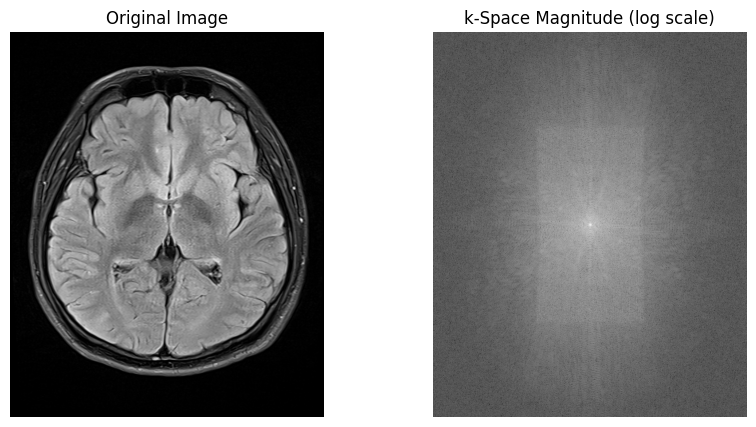

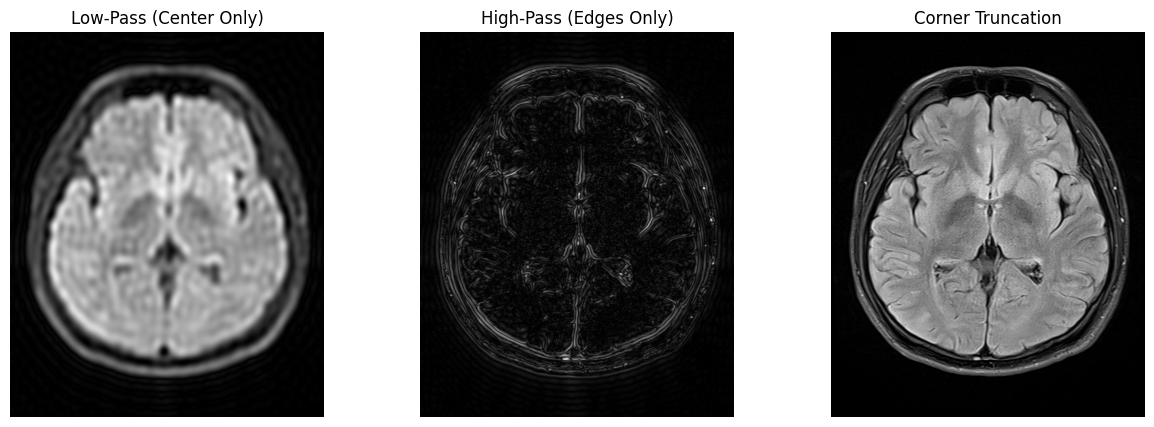

Discussion:
- Center Only (Low-Pass): Retains bulk signal and overall contrast, but image is very blurry (lost fine detail).
- Edges Only (High-Pass): Removes overall contrast; only sharp edges and fine details are visible.
- Corner Truncation: Appears mostly normal, but may exhibit slight ringing (Gibbs artifact) or minor loss of very fine diagonal details due to missing high spatial frequencies in the corners.


In [ ]:
print("=== Coding Exercise 3: k-Space and Reconstruction ===")

from pathlib import Path

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("`ipywidgets` is required for the slice viewer. Install with: %pip install ipywidgets") from exc

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

try:
    import pydicom
except ImportError as exc:
    raise ImportError("`pydicom` is required. Install with: %pip install pydicom") from exc

def find_example_dicom() -> Path:
    # Update this path to point to your example DICOM file (IMG-0002-00001.dcm)
    # Example: Path("/Users/yourname/Desktop/DICOMS/IMG-0002-00001.dcm")

    dicom_file = Path("DICOMS/IMG-0002-00001.dcm")  # Update this if needed

    if dicom_file.exists():
        return dicom_file

    raise FileNotFoundError(
        "Could not find IMG-0002-00001.dcm. Please update the path to your local DICOM file."
    )


def normalize_image(image: np.ndarray) -> np.ndarray:
    image = image.astype(np.float32).copy()
    image -= image.min()
    max_value = image.max()
    if max_value > 0:
        image /= max_value
    return image


def extract_slice_stack(pixel_array: np.ndarray) -> np.ndarray:
    if pixel_array.ndim == 2:
        return pixel_array[np.newaxis, ...]
    if pixel_array.ndim == 3:
        return pixel_array
    raise ValueError(f"Expected a 2D image or 3D stack, got shape {pixel_array.shape}")


def set_selected_slice(slice_idx: int):
    slice_idx = int(max(0, min(slice_stack.shape[0] - 1, slice_idx)))
    globals()["selected_slice_idx"] = slice_idx
    globals()["image"] = normalize_image(slice_stack[slice_idx])
    selection_message.value = (
        f"<b>Current selected slice:</b> {slice_idx}. "
        "If you change the slider, rerun this cell or Coding Exercise 4 to use the updated slice."
    )


dicom_path = find_example_dicom()
ds = pydicom.dcmread(dicom_path)
slice_stack = extract_slice_stack(ds.pixel_array.astype(np.float32))
default_slice_idx = slice_stack.shape[0] // 2
selected_slice_idx = int(globals().get("selected_slice_idx", default_slice_idx))
selection_message = widgets.HTML()


def render_slice(slice_idx: int):
    preview = normalize_image(slice_stack[slice_idx])
    plt.figure(figsize=(6, 6))
    plt.imshow(preview, cmap="gray")
    plt.title(f"IMG-0002-00001.dcm | slice {slice_idx}/{slice_stack.shape[0] - 1}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


if slice_stack.shape[0] > 1:
    slice_slider = widgets.IntSlider(
        min=0,
        max=slice_stack.shape[0] - 1,
        step=1,
        value=selected_slice_idx,
        description="Slice",
        continuous_update=False,
        layout=widgets.Layout(width="450px"),
    )

    def on_slice_change(change):
        if change["name"] != "value" or change["new"] is None:
            return
        set_selected_slice(change["new"])

    slice_slider.observe(on_slice_change, names="value")
    display(widgets.HTML(
        "<b>Slice viewer:</b> Move the slider to choose a slice from the middle portion "
        "with clear anatomy boundaries and minimal empty background."
    ))
    display(slice_slider)
    display(selection_message)
    display(widgets.interactive_output(render_slice, {"slice_idx": slice_slider}))
    set_selected_slice(slice_slider.value)
else:
    render_slice(default_slice_idx)
    set_selected_slice(default_slice_idx)

image = globals()["image"]
print(f"Using slice index {int(globals()['selected_slice_idx'])} for k-space analysis.")

# TODO: Compute 2D FFT and shift zero-frequency to center.
k_space = np.fft.fftshift(np.fft.fft2(image))

# TODO: Visualize the source image and log-magnitude k-space.
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
# Add small epsilon to avoid log(0)
k_space_mag = np.log(np.abs(k_space) + 1e-8)
plt.imshow(k_space_mag, cmap='gray')
plt.title('k-Space Magnitude (log scale)')
plt.axis('off')
plt.show()

# TODO: Reconstruct image with inverse FFT.
reconstructed = np.abs(np.fft.ifft2(np.fft.ifftshift(k_space)))

# TODO: Apply central-k-space, no-center, and corner-truncation masks.
rows, cols = k_space.shape
center_row, center_col = rows // 2, cols // 2

# Keep only central k-space (low-pass)
r = 30 # Radius for central mask
y, x = np.ogrid[:rows, :cols]
mask_center = (x - center_col)**2 + (y - center_row)**2 <= r**2
k_space_lowpass = k_space * mask_center
img_lowpass = np.abs(np.fft.ifft2(np.fft.ifftshift(k_space_lowpass)))

# Remove central k-space (high-pass)
mask_edge = ~mask_center
k_space_highpass = k_space * mask_edge
img_highpass = np.abs(np.fft.ifft2(np.fft.ifftshift(k_space_highpass)))

# Truncate high-frequency corners (circular mask)
r_outer = min(rows, cols) // 2
mask_circle = (x - center_col)**2 + (y - center_row)**2 <= r_outer**2
k_space_trunc = k_space * mask_circle
img_trunc = np.abs(np.fft.ifft2(np.fft.ifftshift(k_space_trunc)))

# Plotting the manipulated reconstructions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_lowpass, cmap='gray')
axes[0].set_title('Low-Pass (Center Only)')
axes[0].axis('off')

axes[1].imshow(img_highpass, cmap='gray')
axes[1].set_title('High-Pass (Edges Only)')
axes[1].axis('off')

axes[2].imshow(img_trunc, cmap='gray')
axes[2].set_title('Corner Truncation')
axes[2].axis('off')
plt.show()

# TODO: Compare reconstructions and discuss contrast/detail differences.

print("Discussion:")
print("- Center Only (Low-Pass): Retains bulk signal and overall contrast, but image is very blurry (lost fine detail).")
print("- Edges Only (High-Pass): Removes overall contrast; only sharp edges and fine details are visible.")
print("- Corner Truncation: Appears mostly normal, but may exhibit slight ringing (Gibbs artifact) or minor loss of very fine diagonal details due to missing high spatial frequencies in the corners.")
# ...

## 2.3 Gradient History and k-Space Trajectory

### **Questions 7**
Consider Cartesian k-space sampling in a 2D GRE sequence.

- a) Explain why each TR usually acquires one readout line but a different $k_y$ value.
- b) Relate k-space spacing to FOV and k-space extent to spatial resolution.
- c) Why does undersampling in the phase-encode direction produce wrap-around?

### **Answers for Questions 7**

- a) Each TR uses a different phase-encoding gradient strength (Gy). This creates a position-dependent phase twist. In k-space, applying a different Gy moves us to a new horizontal line. Therefore, one TR collects one distinct phase-encoded line.

- b) The spacing between k-space lines determines the Field of View. The formula is FOV = 1 / delta_k. The maximum extent of k-space covered determines the spatial resolution. The formula is Resolution (delta_x) = 1 / k_max.

- c) Undersampling means skipping lines, which increases the k-space spacing. Because FOV = 1 / delta_k, increasing spacing decreases the Field of View. If the resulting FOV is smaller than the patient's anatomy, signals from outside the FOV fold over to the opposite side, causing wrap-around.
-----------------------

### **Questions 8**
Compare Cartesian and non-Cartesian trajectories such as radial or spiral.

- a) Which trajectories oversample the center of k-space, and why can that help with motion?
- b) What extra reconstruction challenge appears when sampling is non-uniform?
- c) Give one clinical situation where a radial or spiral trajectory could be preferred, and justify your choice.

### **Answers for Questions 8**

- a) Radial and spiral trajectories oversample the center of k-space. The k-space center controls bulk image contrast and overall signal. Continuously resampling the center averages out signal fluctuations caused by motion, preventing the discrete "ghosting" artifacts typically seen in Cartesian sequences.

- b) Non-uniform sampling cannot be directly reconstructed using a standard FFT. The data must first go through gridding, which interpolates the non-uniformly acquired points onto a uniform Cartesian grid before the inverse FFT can be applied.

- c) Abdominal or cardiac imaging. These areas suffer from severe respiratory, pulsatile, and gross motion. Because non-Cartesian trajectories oversample the k-space center and resist motion ghosting, they allow for free-breathing scans or dynamic imaging of moving organs without severe artifacts.
-----------------------

## 2.4 Undersampling and Acquisition Efficiency

### **Coding Exercise 4**
Reuse the same selected slice from `IMG-0002-00001.dcm` to compare encoding choices and acquisition efficiency.

Tasks:
1. Use the same slice index selected in Coding Exercise 3. If you change the slider in Coding Exercise 3, rerun this cell so it uses the updated slice. If you did not run Exercise 3, the middle slice will be used by default.
2. Implement scan-time estimates for multiple protocol options (TR, N_PE, NEX, ETL).
3. Create at least two undersampling patterns (for example, uniform skip and central-weighted retention).
4. Reconstruct from each sampling pattern and compare artifact severity.
5. Summarize the best speed-vs-quality option for a chosen clinical objective.

In [1]:
#Run this cell to verify the slice viewer is working for the next coding exercises.

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    import pydicom
except ImportError as exc:
    raise ImportError("`pydicom` is required. Install with: %pip install pydicom") from exc

def find_example_dicom() -> Path:
    # Update this path to point to correct DICOM file (IMG-0002-00001.dcm)
    # Example: Path("/Users/yourname/Desktop/DICOMS/IMG-0002-00001.dcm")

    dicom_file = Path("DICOMS/IMG-0002-00001.dcm")  # Update this if needed

    if dicom_file.exists():
        return dicom_file

    raise FileNotFoundError(
        "Could not find IMG-0002-00001.dcm. Please update the path to your local DICOM file."
    )


def normalize_image(image: np.ndarray) -> np.ndarray:
    image = image.astype(np.float32).copy()
    image -= image.min()
    max_value = image.max()
    if max_value > 0:
        image /= max_value
    return image


def extract_slice_stack(pixel_array: np.ndarray) -> np.ndarray:
    if pixel_array.ndim == 2:
        return pixel_array[np.newaxis, ...]
    if pixel_array.ndim == 3:
        return pixel_array
    raise ValueError(f"Expected a 2D image or 3D stack, got shape {pixel_array.shape}")


dicom_path = find_example_dicom()
ds = pydicom.dcmread(dicom_path)
slice_stack = extract_slice_stack(ds.pixel_array.astype(np.float32))
slice_idx = int(globals().get("selected_slice_idx", slice_stack.shape[0] // 2))
slice_idx = max(0, min(slice_stack.shape[0] - 1, slice_idx))
reference_image = normalize_image(slice_stack[slice_idx])

print(f"Using slice index {slice_idx} for encoding comparisons.")


Using slice index 10 for encoding comparisons.


=== Coding Exercise 4: Encoding Efficiency and Trajectory Design ===
Scan Time -> Standard SE: 1680.0s | Fast SE (ETL=8): 210.0s


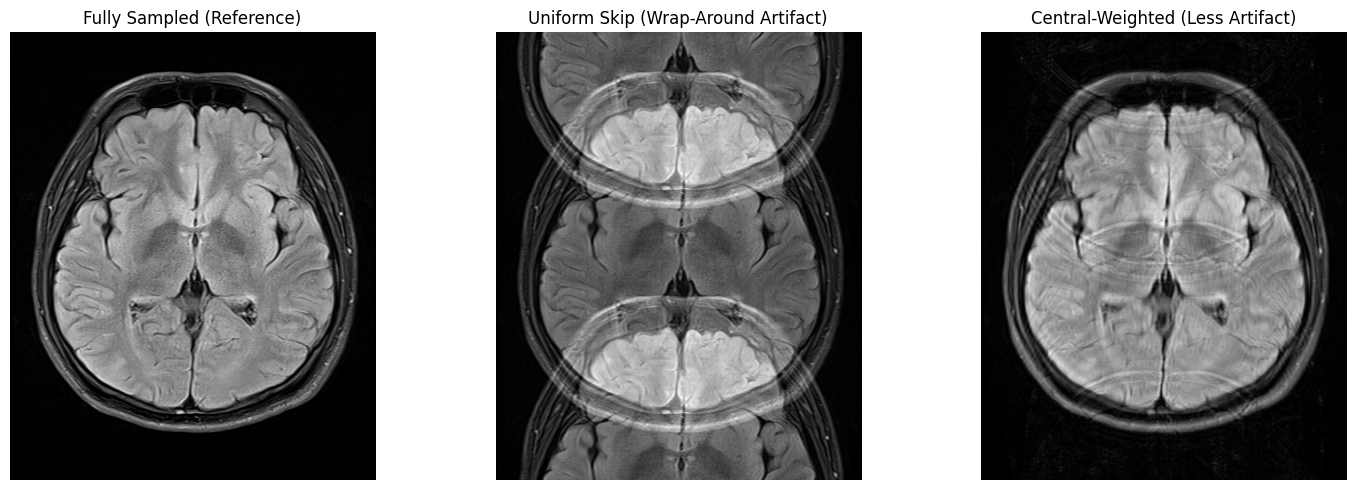


Recommendation: Central-weighted (variable density) undersampling is preferred.
It significantly reduces scan time while avoiding the severe wrap-around (aliasing) 
artifacts seen in uniform undersampling, because it preserves the low spatial 
frequencies responsible for bulk contrast.


In [3]:
print("=== Coding Exercise 4: Encoding Efficiency and Trajectory Design ===")

rows, cols = reference_image.shape

# TODO 1: Define protocol settings and estimate scan time.
tr_ms, n_pe, nex, etl = 2500, rows, 1, 8
time_se = (tr_ms / 1000) * n_pe * nex
time_fse = time_se / etl
print(f"Scan Time -> Standard SE: {time_se:.1f}s | Fast SE (ETL={etl}): {time_fse:.1f}s")

# TODO 2: Compute k-space from the reference image.
kspace = np.fft.fftshift(np.fft.fft2(reference_image))

# TODO 3: Create at least two undersampling masks.
# Mask 1: Uniform undersampling (Skip every 2nd line) - Acceleration factor R=2
mask_uniform = np.zeros_like(kspace)
mask_uniform[::2, :] = 1 

# Mask 2: Variable Density / Central-weighted (Dense center, sparse outer)
mask_vd = np.zeros_like(kspace)
mask_vd[::3, :] = 1  # Sparse outer lines
c_row = rows // 2
mask_vd[c_row - 32 : c_row + 32, :] = 1  # Retain central 64 lines fully


# TODO 4: Reconstruct images for each mask.
img_uni = np.abs(np.fft.ifft2(np.fft.ifftshift(kspace * mask_uniform)))
img_vd = np.abs(np.fft.ifft2(np.fft.ifftshift(kspace * mask_vd)))

# TODO 5: Compare image quality and speed.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(reference_image, cmap='gray')
axes[0].set_title("Fully Sampled (Reference)")

axes[1].imshow(img_uni, cmap='gray')
axes[1].set_title("Uniform Skip (Wrap-Around Artifact)")

axes[2].imshow(img_vd, cmap='gray')
axes[2].set_title("Central-Weighted (Less Artifact)")

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

# TODO 6: Recommend one acquisition strategy.
print("\nRecommendation: Central-weighted (variable density) undersampling is preferred.")
print("It significantly reduces scan time while avoiding the severe wrap-around (aliasing) ")
print("artifacts seen in uniform undersampling, because it preserves the low spatial ")
print("frequencies responsible for bulk contrast.")
# ...

---

# Part 3: Pulse Sequences and Image Weighting Strategies

## Key Concepts

**Gradient Echo (GRE):**
- Uses gradient reversal (no 180° RF pulse)
- Fast imaging, short TR/TE possible
- T2* sensitive (susceptibility effects prominent)

**Spin Echo (SE):**
- Uses 90° + 180° refocusing pulse
- Refocuses static inhomogeneity dephasing
- Produces true T2 contrast

**Fast Spin Echo (FSE/TSE):**
- Multiple echoes per TR (echo train length, ETL)
- Greatly reduces scan time
- Long ETL may introduce T2 blurring

**Inversion Recovery (STIR/FLAIR):**
- Inversion pulse + TI to null specific tissue
- STIR suppresses short-T1 tissues (fat)
- FLAIR suppresses CSF for brain lesion conspicuity

## 3.1 Sequence Selection and Parameter Trade-offs

### **Questions 9**
You need to image a lesion near the paranasal sinuses, where susceptibility effects are strong.

- a) Would GRE or SE better preserve lesion signal? Explain using susceptibility and $T_2^*$ ideas.
- b) If signal dropout is still a problem, would you shorten TE or change sequence family first? Defend your answer.
- c) Why can GRE still be the right choice for some fast 3D exams even in susceptibility-prone regions?

### **Answers for Questions 9**

- a) SE better preserves the signal. SE uses a 180 degree refocusing pulse. This pulse reverses dephasing caused by static magnetic field inhomogeneity. This provides true T2 contrast. GRE lacks this 180 degree pulse, so it suffers from T2* decay, causing severe susceptibility artifacts and signal dropouts near sinuses.

- b) Should change the sequence family first (from GRE to SE). Changing to a SE sequence actively refocuses the magnetic field inhomogeneities using the 180 degree pulse. Shortening TE in a GRE sequence gives the signal less time to dephase, but it does not fix the underlying susceptibility artifact problem.

- c) GRE is extremely fast because it uses small flip angles and very short TRs. This speed makes high-resolution 3D imaging and single breath-hold scans practical. Sometimes, capturing a rapid 3D volume is clinically more important than eliminating susceptibility artifacts.
---------------
### **Questions 10**
An FSE sequence uses $TR=4000$ ms, $N_{PE}=256$, and $NEX=1$.

- a) Compute scan time for standard SE ($ETL = 1$), FSE with $ETL = 8$, and FSE with $ETL = 16$.
- b) Why does long ETL reduce image sharpness?
- c) For a routine T2-weighted brain exam, what ETL range would you choose, and why?

### **Answers for Questions 10**

- a) Scan time formula is Time = (TR * N_PE) / ETL

For standard SE (ETL = 1): Time = 4000 ms * 256 / 1 = 1024 seconds

For FSE (ETL = 8): Time = 1024 / 8 = 128 seconds

For FSE (ETL = 16): Time = 1024 / 16 = 64 seconds

- b) In Fast SE, each echo in the echo train is collected at a different TE. Later echoes experience more T2 decay, resulting in lower signal amplitude. This signal variation across the phase-encoding steps in k-space causes blurring (T2 blurring) in the final image.

- c) An ETL range of 8 to 16 is typical and recommended. This range offers a great balance. It makes the scan much faster than standard SE, which is important for long-TR sequences. At the same time, it keeps T2 decay blurring to an acceptable level compared to excessively long ETLs.
--------------------------------

## 3.2 Sequence Timing and Contrast Simulator

### **Coding Exercise 5**
Build a simplified MRI sequence simulator to compare contrast behavior across GRE, SE, and IR-style timing.

Tasks:
1. Define representative tissue parameters ($T_1$, $T_2$, $T_2^*$).
2. Implement simplified signal models:
   - GRE: $S \propto (1-e^{-TR/T_1})e^{-TE/T_2^*}$
   - SE: $S \propto (1-e^{-TR/T_1})e^{-TE/T_2}$
   - IR (long TR approximation): $M_z(TI)=M_0(1-2e^{-TI/T_1})$
3. Sweep TE and TR, and visualize signal trends.
4. Demonstrate tissue nulling with TI (e.g., STIR-like fat suppression, FLAIR-like CSF suppression).
5. Interpret which parameter combinations best match each intended weighting.

**Helpful Note:** Review **Lecture 27** notes on GRE/SE and inversion recovery (STIR/FLAIR). You can also use the scan-time discussion in **Question 10** and the null-TI idea in **Question 11** to guide your interpretation.

=== Coding Exercise 5: Pulse Sequence Contrast Simulator ===


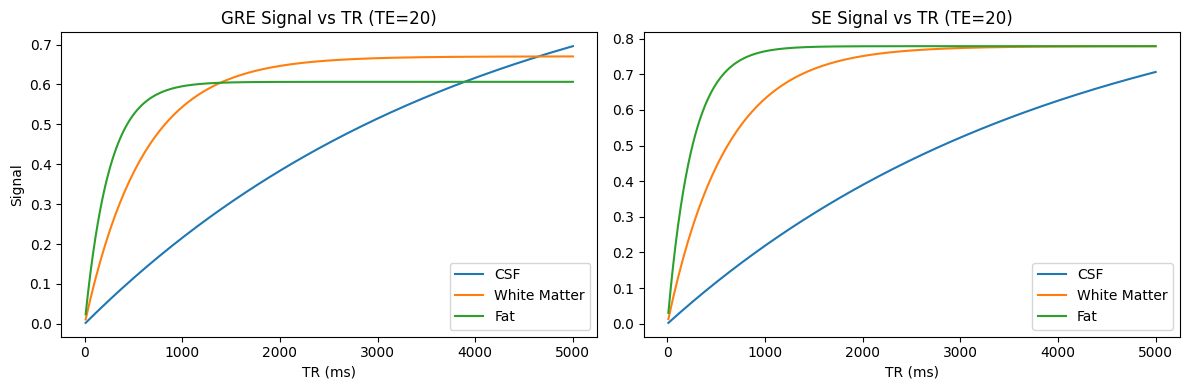

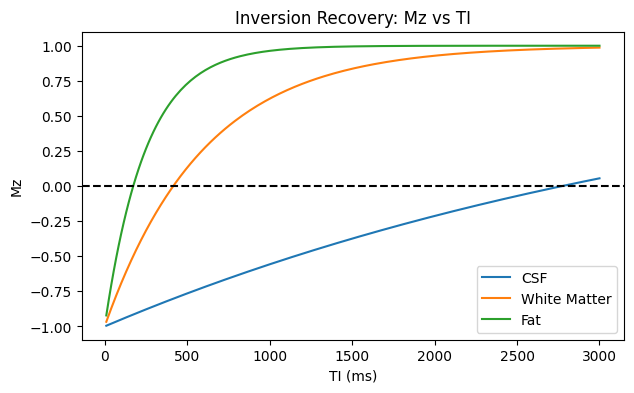

STIR Null Time (Fat): 173.3 ms
FLAIR Null Time (CSF): 2772.6 ms

Interpretation:
1. GRE signals decay faster than SE because T2* < T2, making GRE highly susceptible to field inhomogeneities.
2. Inversion Recovery (IR) starts at -M0. By setting the readout time (TI) exactly when a tissue's Mz curve crosses zero, that tissue's signal is completely nulled.
3. STIR uses a short TI to null fat, while FLAIR uses a long TI to null fluid (CSF).


In [5]:
print("=== Coding Exercise 5: Pulse Sequence Contrast Simulator ===")

import matplotlib.pyplot as plt
import numpy as np

M0 = 1.0


def gre_signal(tr_ms, te_ms, t1_ms, t2star_ms):
    return (1 - np.exp(-tr_ms / t1_ms)) * np.exp(-te_ms / t2star_ms)


def se_signal(tr_ms, te_ms, t1_ms, t2_ms):
    return (1 - np.exp(-tr_ms / t1_ms)) * np.exp(-te_ms / t2_ms)


def ir_mz(ti_ms, t1_ms, m0=1.0):
    return m0 * (1 - 2 * np.exp(-ti_ms / t1_ms))


def null_ti(t1_ms):
    return t1_ms * np.log(2)


# TODO 1: Define tissue parameters.
tissues = {
    'CSF': {'T1': 4000, 'T2': 2000, 'T2star': 800},
    'White Matter': {'T1': 600, 'T2': 80, 'T2star': 50},
    'Fat': {'T1': 250, 'T2': 80, 'T2star': 40}
}

# TODO 2: Create TR, TE, and TI sweeps.

tr_sweep = np.linspace(10, 5000, 200)
ti_sweep = np.linspace(10, 3000, 200)
fixed_te = 20  # Fixed TE for TR sweep

# TODO 3: Compute GRE and SE signal trends.
gre_tr_trends = {name: gre_signal(tr_sweep, fixed_te, t['T1'], t['T2star']) 
                 for name, t in tissues.items()}
se_tr_trends = {name: se_signal(tr_sweep, fixed_te, t['T1'], t['T2']) 
                for name, t in tissues.items()}

# TODO 4: Plot GRE and SE signal behavior.
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for name, val in gre_tr_trends.items(): plt.plot(tr_sweep, val, label=name)
plt.title(f'GRE Signal vs TR (TE={fixed_te})')
plt.xlabel('TR (ms)'), plt.ylabel('Signal'), plt.legend()

plt.subplot(1, 2, 2)
for name, val in se_tr_trends.items(): plt.plot(tr_sweep, val, label=name)
plt.title(f'SE Signal vs TR (TE={fixed_te})')
plt.xlabel('TR (ms)'), plt.legend()

plt.tight_layout()
plt.show()

# TODO 5: Compute inversion-recovery curves across TI.
ir_curves = {name: ir_mz(ti_sweep, t['T1']) for name, t in tissues.items()}

plt.figure(figsize=(7, 4))
for name, val in ir_curves.items(): plt.plot(ti_sweep, val, label=name)
plt.axhline(0, color='black', linestyle='--')
plt.title('Inversion Recovery: Mz vs TI')
plt.xlabel('TI (ms)'), plt.ylabel('Mz'), plt.legend()
plt.show()

# TODO 6: Estimate STIR-like and FLAIR-like null times.
null_fat = null_ti(tissues['Fat']['T1'])
null_csf = null_ti(tissues['CSF']['T1'])

print(f"STIR Null Time (Fat): {null_fat:.1f} ms")
print(f"FLAIR Null Time (CSF): {null_csf:.1f} ms")

# TODO 7: Add a short interpretation of the contrast behavior.
print("\nInterpretation:")
print("1. GRE signals decay faster than SE because T2* < T2, making GRE highly susceptible to field inhomogeneities.")
print("2. Inversion Recovery (IR) starts at -M0. By setting the readout time (TI) exactly when a tissue's Mz curve crosses zero, that tissue's signal is completely nulled.")
print("3. STIR uses a short TI to null fat, while FLAIR uses a long TI to null fluid (CSF).")

# ...

## 3.3 Inversion Recovery Case Analysis

### **Questions 11**
You are selecting between STIR and FLAIR for two clinical applications.

- a) For edema near fat and for periventricular brain lesions, which sequence would you choose in each case, and why?
- b) Using $TI_{null} \approx T_1\ln 2$, estimate the null TI for fat with $T_1 = 250$ ms and for CSF with $T_1 = 4000$ ms.
- c) Why is STIR generally avoided after gadolinium enhancement?

### **Answers for Questions 11**

- a) For edema near fat, choose STIR. STIR suppresses the bright fat signal, allowing the bright fluid to be clearly seen. For periventricular brain lesions, choose FLAIR. FLAIR suppresses the bright CSF signal in the ventricles, making the bright lesions visible instead of being hidden by fluid.

- b) For fat (T1 = 250 ms): TI_null = 250 * ln(2) = 250 * 0.693 = 173 ms

For CSF (T1 = 4000 ms): TI_null = 4000 * ln(2) = 4000 * 0.693 = 2772 ms

- c) Gadolinium shortens the T1 of enhancing tissues. Their new shortened T1 may become very close to the T1 of fat. If a STIR sequence is used, the short TI designed to suppress fat will accidentally suppress the gadolinium-enhanced lesions as well, making them invisible.
------------------------

### **Questions 12**
A protocol engineer proposes replacing all SE scans with GRE to reduce scan time.

- a) Give three clinical situations where this would be a poor choice.
- b) Propose a mixed GRE and SE/FSE protocol strategy, and justify it.
- c) Name one hardware or safety issue that also argues against relying on only one sequence family.

### **Answers for Questions 12**

- a) Imaging near the sinuses or skull base (high susceptibility artifacts).

Examining patients with metal implants or dental work (causes massive signal voids in GRE).

When true T2 contrast is needed for specific pathology detection (GRE only provides T2* contrast).

- b) Use FSE for routine 2D anatomical T1/T2 imaging; it provides true contrast and resists susceptibility artifacts reasonably fast. Use GRE for 3D acquisitions, angiography, or breath-hold abdominal scans where extreme speed is critical and susceptibility is either less of an issue or intentionally desired (e.g., detecting hemorrhage).

- c) Relying solely on FSE poses a high SAR (tissue heating) risk due to the many 180 degree RF pulses. Relying solely on ultra-fast GRE sequences demands extremely rapid gradient switching, increasing the risk of Peripheral Nerve Stimulation (PNS) and high acoustic noise.
----------------------------

## 3.4 Inversion Recovery and Echo-Train Trade-off Simulation

### **Coding Exercise 6**
Implement a simulation that links inversion recovery behavior with FSE timing trade-offs.

Tasks:
1. Compute $M_z(TI)=M_0(1-2e^{-TI/T_1})$ for fat-like and CSF-like tissues.
2. Estimate TI values that null each tissue class.
3. Simulate scan-time changes for ETL = 1, 8, 16, 24 using fixed TR and $N_{PE}$.
4. Build a short decision table: when to prioritize STIR/FLAIR contrast vs faster FSE acquisition.

**Helpful Note:** You can use **Question 11** values directly for fat and CSF. Review **Lecture 27** notes on inversion recovery and FSE/ETL trade-offs.

In [6]:
print("=== Coding Exercise 6: IR Nulling and Echo-Train Trade-offs ===")

import numpy as np

M0 = 1.0

def ir_mz(ti_ms, t1_ms, m0=1.0):
    return m0 * (1 - 2 * np.exp(-ti_ms / t1_ms))


def null_ti(t1_ms):
    return t1_ms * np.log(2)


def estimate_scan_time_seconds(tr_ms, n_pe, nex, etl):
    etl = max(1, int(etl))
    return (tr_ms / 1000.0) * (n_pe / etl) * nex


# TODO 1: Define T1 values for fat-like and CSF-like tissues.
t1_fat = 250.0   # ms
t1_csf = 4000.0  # ms

# TODO 2: Create a TI sweep.
ti_sweep = np.linspace(10, 5000, 500)

# TODO 3: Compute Mz(TI) and identify the null point for each tissue.
mz_fat = ir_mz(ti_sweep, t1_fat)
mz_csf = ir_mz(ti_sweep, t1_csf)

null_fat_val = null_ti(t1_fat)
null_csf_val = null_ti(t1_csf)

# TODO 4: Summarize the null TI values.
print(f"Null TI for Fat (STIR-like): {null_fat_val:.1f} ms")
print(f"Null TI for CSF (FLAIR-like): {null_csf_val:.1f} ms")

# TODO 5: Compute scan times for ETL = 1, 8, 16, 24.
tr_ms = 4000.0  # Long TR for T2W/FLAIR
n_pe = 256
nex = 1
etls = [1, 8, 16, 24]
print("\n--- Scan Time Estimates (TR=4000ms, NPE=256, NEX=1) ---")

# TODO 6: Build a short comparison table or list.
for etl in etls:
    time_sec = estimate_scan_time_seconds(tr_ms, n_pe, nex, etl)
    print(f"ETL = {etl:2d} -> Scan Time: {time_sec:6.1f} s ({time_sec/60:.1f} min)")

# TODO 7: Add a short decision summary.
print("\nDecision Summary:")
print("1. If finding edema near fat is critical, prioritize STIR (short TI).")
print("2. If finding periventricular lesions (MS) is critical, prioritize FLAIR (long TI).")
print("3. Both IR sequences demand long TRs. FSE is mandatory (ETL 8-16) to keep ")
print("   scan times clinically acceptable (< 5 mins) without causing excessive T2 blurring.")

# ...

=== Coding Exercise 6: IR Nulling and Echo-Train Trade-offs ===
Null TI for Fat (STIR-like): 173.3 ms
Null TI for CSF (FLAIR-like): 2772.6 ms

--- Scan Time Estimates (TR=4000ms, NPE=256, NEX=1) ---
ETL =  1 -> Scan Time: 1024.0 s (17.1 min)
ETL =  8 -> Scan Time:  128.0 s (2.1 min)
ETL = 16 -> Scan Time:   64.0 s (1.1 min)
ETL = 24 -> Scan Time:   42.7 s (0.7 min)

Decision Summary:
1. If finding edema near fat is critical, prioritize STIR (short TI).
2. If finding periventricular lesions (MS) is critical, prioritize FLAIR (long TI).
3. Both IR sequences demand long TRs. FSE is mandatory (ETL 8-16) to keep 
   scan times clinically acceptable (< 5 mins) without causing excessive T2 blurring.


---

# Part 4: Advanced MRI, Artifacts, and Safety

## Key Concepts

**Diffusion-Weighted Imaging (DWI):**
- Sensitive to Brownian motion of water
- Signal model: $S=S_0e^{-bD}$
- Restricted diffusion appears bright on DWI and dark on ADC maps

**Echo Planar Imaging (EPI):**
- Very fast acquisition (often one excitation)
- Enables DWI/fMRI but is prone to distortion and ghosting

**Common Artifacts:**
- Motion ghosting (phase-encode direction)
- Aliasing/wrap-around (insufficient FOV)
- Chemical shift (fat-water frequency mismatch)
- Susceptibility distortion/signal loss (metal, air interfaces)
- Gibbs/truncation ringing (finite k-space sampling)

**MRI Safety Domains:**
- Static field hazards (projectiles, implants)
- RF heating and SAR limits
- Gradient hazards (PNS, acoustic noise)
- Strict screening and zone control are essential

## 4.1 Diffusion and EPI Interpretation

### **Questions 13**
A patient with acute neurologic deficit has:
- DWI: focal bright signal in right MCA territory
- ADC map: corresponding dark region

- a) Interpret this finding physiologically, and explain why DWI can detect acute ischemia earlier than CT.
- b) What is T2 shine-through, and how does the ADC map help distinguish it from true restricted diffusion?
- c) Why is EPI commonly used for DWI even though it is sensitive to distortion?

### **Answers for Questions 13**
- a) This indicates true restricted diffusion caused by cytotoxic edema (acute stroke). Cells swell and the extracellular space shrinks, trapping water. DWI detects this Brownian motion restriction within minutes. CT and conventional MRI rely on structural or fluid changes that take hours to appear, making DWI much faster.

- b) T2 shine-through occurs when tissue with a very long T2 appears bright on DWI, falsely mimicking restricted diffusion. The ADC map calculates pure diffusion, removing this T2 effect. True restricted diffusion is bright on DWI and dark on ADC. T2 shine-through is bright on DWI but normal/bright on ADC.

- c) DWI uses strong gradients to measure microscopic water motion. Any macroscopic patient motion completely destroys this signal. EPI is ultra-fast, capturing the entire image in 50-100 ms. This freezes gross patient motion, making EPI the only practical way to acquire DWI despite its susceptibility artifacts.
--------------------
### **Questions 14**
Given $S=S_0e^{-bD}$, compare expected diffusion signal for:
- Tissue X: $D=0.4\times10^{-3}\ \mathrm{mm^2/s}$
- Tissue Y: $D=1.0\times10^{-3}\ \mathrm{mm^2/s}$
for $b=1000\ \mathrm{s/mm^2}$.

- a) Compute normalized signals $S/S_0$ for both tissues.
- b) Which tissue appears brighter on high-b DWI, and why?
- c) What is gained and what is lost when b-value is increased?
- d) Why are at least two b-values needed for ADC, and why are more than two often useful?

### **Answers for Questions 14**
- a) Using the formula S/S0 = e^(-bD):

For Tissue X: S/S0 = e^(-1000 * 0.0004) = e^(-0.4) = 0.670

For Tissue Y: S/S0 = e^(-1000 * 0.001) = e^(-1.0) = 0.368

- b) Tissue X appears brighter. It has a lower diffusion coefficient (D), indicating restricted water motion. Because its D is smaller, it suffers less signal decay (retaining 67% of its signal versus 37% for Tissue Y). Therefore, restricted diffusion appears bright on DWI.

- c) Gained: More diffusion weighting and greater contrast between normal tissue and restricted diffusion tissue.
Lost: Overall Signal-to-Noise Ratio (SNR). Because b increases the exponential decay for all tissues, the entire image becomes darker and noisier.

- d) Two b-values (e.g., b=0 and b=1000) are mathematically required to solve for the unknown ADC and eliminate the T2-dependent S0 variable. Using more than two b-values allows for linear regression curve-fitting, which reduces noise variance and makes the ADC calculation more accurate.
--------------------------

## 4.2 DICOM Slice Navigation and Display-Window Analysis

### **Coding Exercise 7**
Use the DICOM slice viewer to study how display settings affect what anatomy is visible. The DICOM folder contains **6 series from a right knee MRI exam**. Use the table below to orient yourself before choosing a series:

| Series | Weighting | Plane |
|--------|-----------|-------|
| `series-000001` | Proton density | Axial |
| `series-000002` | Proton density | Coronal |
| `series-000003` | T1-weighted | Coronal |
| `series-000004` | Localizer only | Multi |
| `series-000005` | PD + fat suppression | Sagittal |
| `series-000006` | T2-weighted | Sagittal |

**Note:** `series-000004` is a quick scout/localizer used for planning — it has very low contrast and is not useful for this exercise. Choose any of the other five series.

**PART A: Choose your data**
1. Pick **one series** from the dropdown.
2. Select **3 slice indices** from that series, spread across the stack (early, middle, late).
3. Record your 3 chosen slice numbers.

**PART B: Compare display settings**
For each of the 3 slices, evaluate all three settings below:
1. **Baseline:** Low % = 2, High % = 98
2. **Higher contrast:** Low % = 10, High % = 90
3. **Wider range:** Low % = 1, High % = 99

**PART C: Required output figure**
1. Create one figure arranged as **3 rows × 3 columns**:
   - Rows = your 3 selected slice indices
   - Columns = the 3 display settings above
2. Add clear titles/labels with slice index and (% low, % high).

**PART D: Short analysis**
1. For each slice, choose the setting that best shows anatomy boundaries.
2. Briefly state what became easier/harder to see as you changed % settings.
3. Explain in 3-5 sentences why changing Low%/High% changes visibility even though underlying pixel data is unchanged.

In [ ]:
# Run this cell to load the slice viewer for the next coding exercises.

from pathlib import Path

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError("`ipywidgets` is required for the slice viewer. Install with: %pip install ipywidgets") from exc

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

try:
    import pydicom
except ImportError as exc:
    raise ImportError("`pydicom` is required. Install with: %pip install pydicom") from exc


def find_dicom_root() -> Path:
    # Update this path to point to your own "DICOMS" folder location.
    # Example: Path("/Users/yourname/Desktop/DICOMS")

    dicom_path = Path("DICOMS") # Update this if needed

    if dicom_path.exists() and dicom_path.is_dir():
        return dicom_path

    raise FileNotFoundError(
        "Could not find the DICOMS folder. Please update the path to your local DICOMS directory."
    )

def dicom_sort_key(ds, path: Path):
    instance_number = getattr(ds, "InstanceNumber", None)
    if instance_number is not None:
        try:
            return (0, int(instance_number))
        except Exception:
            pass

    position = getattr(ds, "ImagePositionPatient", None)
    if position is not None:
        try:
            return (1, float(position[-1]))
        except Exception:
            pass

    return (2, path.name)


def load_series(series_dir: Path):
    dicom_paths = sorted(series_dir.glob("*.dcm"))
    if not dicom_paths:
        raise ValueError(f"No DICOM files found in {series_dir}")

    slice_records = []
    for dicom_path in dicom_paths:
        ds = pydicom.dcmread(dicom_path)
        pixel_array = ds.pixel_array.astype(np.float32)
        slice_records.append((dicom_sort_key(ds, dicom_path), pixel_array))

    slice_records.sort(key=lambda item: item[0])
    return np.stack([record[1] for record in slice_records], axis=0)


def window_image(image: np.ndarray, low_pct: int = 2, high_pct: int = 98):
    low_pct = max(0, min(99, low_pct))
    high_pct = max(low_pct + 1, min(100, high_pct))

    lo, hi = np.percentile(image, (low_pct, high_pct))
    if np.isclose(lo, hi):
        lo = float(np.min(image))
        hi = float(np.max(image))
        if np.isclose(lo, hi):
            hi = lo + 1.0

    return np.clip(image, lo, hi), float(lo), float(hi)


def create_slice_viewer(series_data: dict):
    series_names = sorted(series_data.keys())
    default_series = series_names[0]
    default_volume = series_data[default_series]

    series_dropdown = widgets.Dropdown(
        options=series_names,
        value=default_series,
        description="Series",
        layout=widgets.Layout(width="300px"),
    )
    slice_slider = widgets.IntSlider(
        min=0,
        max=default_volume.shape[0] - 1,
        step=1,
        value=default_volume.shape[0] // 2,
        description="Slice",
        continuous_update=False,
        layout=widgets.Layout(width="450px"),
    )
    low_slider = widgets.IntSlider(
        min=0,
        max=30,
        step=1,
        value=2,
        description="Low %",
        continuous_update=False,
        layout=widgets.Layout(width="280px"),
    )
    high_slider = widgets.IntSlider(
        min=70,
        max=100,
        step=1,
        value=98,
        description="High %",
        continuous_update=False,
        layout=widgets.Layout(width="280px"),
    )

    def on_series_change(change):
        if change["name"] != "value" or change["new"] is None:
            return
        volume = series_data[change["new"]]
        slice_slider.max = volume.shape[0] - 1
        slice_slider.value = volume.shape[0] // 2

    series_dropdown.observe(on_series_change, names="value")

    def render(series_name, slice_idx, low_pct, high_pct):
        volume = series_data[series_name]
        image = volume[slice_idx]
        image_disp, lo, hi = window_image(image, low_pct, high_pct)

        plt.figure(figsize=(6, 6))
        plt.imshow(image_disp, cmap="gray", vmin=lo, vmax=hi)
        plt.title(f"{series_name} | slice {slice_idx}/{volume.shape[0] - 1}")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    controls = {
        "series_name": series_dropdown,
        "slice_idx": slice_slider,
        "low_pct": low_slider,
        "high_pct": high_slider,
    }

    viewer_output = widgets.interactive_output(render, controls)
    ui = widgets.VBox([
        widgets.HTML("<b>Interactive DICOM Slice Viewer</b>"),
        widgets.HBox([series_dropdown, slice_slider]),
        widgets.HBox([low_slider, high_slider]),
        viewer_output,
    ])
    display(ui)


# Load DICOM series and launch the slice viewer
dicom_root = find_dicom_root()
series_dirs = sorted([path for path in dicom_root.iterdir() if path.is_dir() and path.name.startswith("series-")])

if not series_dirs:
    raise ValueError(f"No series-* folders found under {dicom_root}")

series_data = {series_dir.name: load_series(series_dir) for series_dir in series_dirs}

create_slice_viewer(series_data)


=== Coding Exercise 7: Windowing Comparison Figure ===


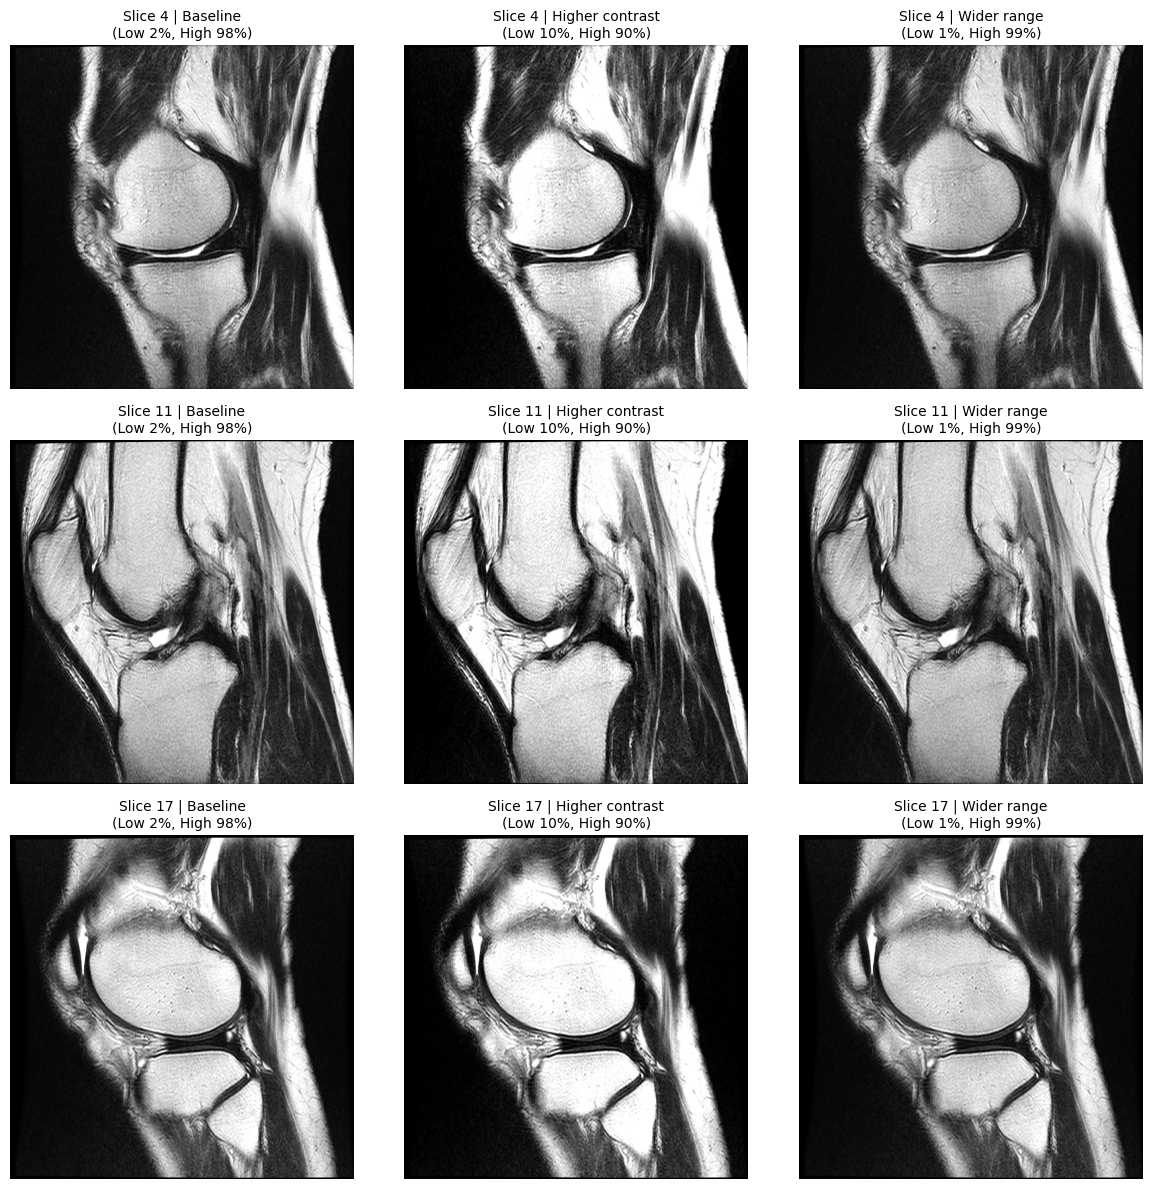

--- Short Analysis ---
1. Best Setting: The 'Higher contrast' (Low 10%, High 90%) setting best shows anatomy boundaries (e.g., bone/cartilage margins) for these slices.
2. Visual Changes: Increasing the Low % (from 2 to 10) darkened the background and suppressed low-intensity noise. Decreasing the High % (from 98 to 90) made bright tissues (like fat/fluid) appear whiter. Together, this pulled mid-tones apart, increasing contrast.
3. Why it works: The underlying DICOM pixel values do not change. Windowing merely shifts the black-to-white visual colormap over a narrower range of the pixel data, forcing subtle differences in pixel intensity to be displayed as starkly different shades of gray.


In [2]:
print("=== Coding Exercise 7: Windowing Comparison Figure ===")

import matplotlib.pyplot as plt

# TODO 1: Choose one series and three slice indices.
series_name = "series-000006" 
volume = series_data[series_name]
num_slices = volume.shape[0]

slices =[int(num_slices * 0.2), int(num_slices * 0.5), int(num_slices * 0.8)]

# TODO 2: Define the three display settings.
settings =[
    {"name": "Baseline", "low": 2, "high": 98},
    {"name": "Higher contrast", "low": 10, "high": 90},
    {"name": "Wider range", "low": 1, "high": 99}
]

# TODO 3: Build the 3 x 3 comparison figure.
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, slc_idx in enumerate(slices):
    img = volume[slc_idx]
    for j, setting in enumerate(settings):
        # Use the provided window_image function
        img_disp, lo, hi = window_image(img, setting["low"], setting["high"])
        
        ax = axes[i, j]
        ax.imshow(img_disp, cmap="gray", vmin=lo, vmax=hi)
        title = f"Slice {slc_idx} | {setting['name']}\n(Low {setting['low']}%, High {setting['high']}%)"
        ax.set_title(title, fontsize=10)
        ax.axis("off")

plt.tight_layout()
plt.show()

# TODO 4: Add a short analysis of which setting best shows anatomy boundaries.
print("--- Short Analysis ---")
print("1. Best Setting: The 'Higher contrast' (Low 10%, High 90%) setting best shows anatomy boundaries (e.g., bone/cartilage margins) for these slices.")
print("2. Visual Changes: Increasing the Low % (from 2 to 10) darkened the background and suppressed low-intensity noise. Decreasing the High % (from 98 to 90) made bright tissues (like fat/fluid) appear whiter. Together, this pulled mid-tones apart, increasing contrast.")
print("3. Why it works: The underlying DICOM pixel values do not change. Windowing merely shifts the black-to-white visual colormap over a narrower range of the pixel data, forcing subtle differences in pixel intensity to be displayed as starkly different shades of gray.")
# ...

## 4.3 MRI Safety Scenario Analysis

### **Questions 15**
A patient arrives for MRI with uncertain implant documentation.

- a) Outline a safe decision pathway before scanning.
- b) Distinguish MR Safe, MR Conditional, and MR Unsafe, and explain why “the scanner is off” is not a valid safety assumption.
- c) If a medical emergency occurs in Zone IV, what should happen first and why?

### **Answers for Questions 15**

- a) Use a written questionnaire, perform verbal confirmation, use a metal detector, and remove all metal objects. If the implant documentation remains uncertain, the key rule is: when in doubt, do not scan until safety is definitively confirmed.

- b) MR Safe: safe in all environments. MR Conditional: safe only under specific parameter limits. MR Unsafe: never safe. "The scanner is off" is invalid because the superconducting static magnetic field (B0) is always on. Projectile hazards exist 24/7.

- c) Remove the patient from Zone IV immediately to a safe area. Emergency medical equipment like oxygen tanks and defibrillators are highly ferromagnetic. Bringing them into Zone IV creates lethal projectile hazards due to the always-on static field.
-----------------

### **Questions 16**
You are optimizing a high-field MRI protocol and observe elevated SAR estimates.

- a) List sequence choices that tend to increase SAR.
- b) Suggest practical protocol changes that reduce SAR while keeping the exam diagnostic.
- c) How are RF heating hazards different from gradient-related acoustic noise or PNS?
- d) Why are patient screening and in-scan monitoring still necessary even after protocol optimization?

### **Answers for Questions 16**
- a) Factors that increase SAR include higher static magnetic fields (B0), higher RF flip angles, more frequent RF pulses (such as high Echo Train Length in Fast Spin Echo), and shorter TR.

- b) To reduce SAR, you can increase the TR to allow more cooling time between pulses. You can also reduce the RF flip angle or decrease the number of RF pulses (for example, by lowering the Echo Train Length in FSE).

- c) RF heating deposits energy via the B1 field, causing tissue burns. Gradient hazards involve rapidly switching magnetic fields. These changing fields induce electrical currents causing Peripheral Nerve Stimulation, and make coils vibrate causing loud acoustic noise.

- d) Patients have individual risk factors like fever, impaired thermoregulation, or undiscovered conductive implants (like metallic fragments or wires). These can cause unexpected severe heating even if the protocol SAR is within FDA limits, requiring constant monitoring.

----------------

## 4.4 Design Component: MRI Acquisition + Reconstruction

### **Coding Exercise 8**
In this design task, you will act like an MRI protocol designer for **one** clinical problem. Your goal is to choose a reasonable scan approach, show how the data would be acquired and reconstructed, and explain why your final design is a good choice.

### **Choose ONE scenario**
1. **Acute ischemic stroke detection**: focus on diffusion sensitivity and speed.
2. **Brain lesion near sinuses**: focus on reducing susceptibility-related signal loss and distortion.
3. **Musculoskeletal edema near fat**: focus on fluid sensitivity and fat suppression.

### **Part A — Protocol Definition**
Define the MRI protocol you would use.
1. Choose a sequence family and briefly explain why it fits the scenario.
2. Specify reasonable imaging parameters: TR, TE, TI (if used), flip angle, matrix, FOV, N_PE, NEX, ETL.
3. Estimate scan time and describe the expected image weighting or contrast.

### **Part B — Acquisition Strategy**
Explain how the data will be collected in k-space.
1. Choose a strategy such as full Cartesian, partial Fourier, accelerated undersampling, or a non-Cartesian option.
2. Explain what you expect to gain in speed.
3. Explain what artifact or image-quality risk this choice introduces.

### **Part C — Reconstruction and Comparison**
Show two versions of the reconstruction.
1. Create one **baseline reconstruction** using your standard approach.
2. Create one **alternative reconstruction** that is either faster or more robust.
3. Compare the two using at least one quantitative measure and a short qualitative comment.
4. State which version you would actually choose for this scenario.

### **Part D — Safety + Final Recommendation**
Finish with a clinically reasonable recommendation.
1. List safety issues that matter for your scenario (for example: SAR, implant screening, static-field concerns, acoustic noise, or PNS).
2. Give a final recommendation that clearly states:
   - which protocol you would use
   - why it fits the clinical problem
   - what trade-off you are accepting

 **Helpful Note:** You may reuse a reference image from earlier coding exercises, or use your own/synthetic image and state assumptions.

=== Coding Exercise 8: MRI Design Component ===
--- PART A: Protocol Definition ---
Scenario: Acute Ischemic Stroke Detection (DWI)
Sequence: Single-Shot EPI (Diffusion Weighted)
TR_ms: 6000
TE_ms: 80
Flip_Angle: 90
FOV: 240 mm
Matrix: 256x256
N_PE: 256
NEX: 1
ETL: 256
Estimated Scan Time (1 slice volume): 6.0 seconds
Contrast: Strong T2-weighting mixed with diffusion weighting (b=1000).
Restricted diffusion (stroke) will appear bright.

--- PART B: Acquisition Strategy ---
Strategy: Partial Fourier EPI (sampling only 62.5% of k-space).
Speed Benefit: Reduces the echo train length, decreasing TE and making the readout faster.
Quality Risk: Minor loss of spatial resolution/SNR, but crucially reduces geometric distortion and T2* blurring, which are the main risks of full EPI.

--- PART C: Reconstruction and Comparison ---
RMSE of Partial Fourier vs Baseline: 0.0214
Qualitative Comparison: The Partial Fourier image retains overall contrast and structure, but looks slightly smoother/blurri

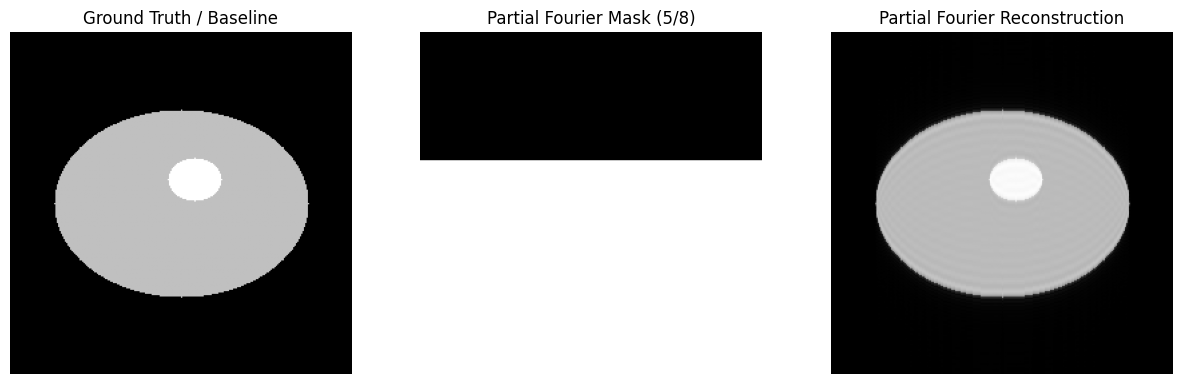

--- PART D: Safety + Final Recommendation ---
Safety Issues:
- PNS (Peripheral Nerve Stimulation): Extremely rapid gradient switching required for EPI can cause nerve tingling.
- Acoustic Noise: The fast gradient toggling will produce deafening noise; earplugs are strictly mandatory.

Final Recommendation:
I recommend the Partial Fourier Single-Shot EPI protocol.
- Why it fits: It freezes macroscopic motion instantly, which is the only way to capture the microscopic Brownian motion required for stroke detection.
- Trade-off accepted: We accept heavy susceptibility artifacts, poor anatomical detail, and loud acoustic noise in exchange for unmatched speed and the ability to detect ischemic tissue within minutes.


In [3]:
print("=== Coding Exercise 8: MRI Design Component ===")

import matplotlib.pyplot as plt
import numpy as np


def estimate_scan_time_seconds(protocol):
    etl = max(1, int(protocol.get("ETL", 1) or 1))
    return (protocol["TR_ms"] / 1000.0) * (protocol["N_PE"] / etl) * protocol["NEX"]


def get_reference_image():
    if "reference_image" in globals():
        return reference_image
    if "image" in globals():
        return image

    rows, cols = 256, 256
    rr, cc = np.ogrid[:rows, :cols]
    phantom = np.zeros((rows, cols), dtype=np.float32)
    body_mask = ((rr - rows / 2) ** 2) / (70 ** 2) + ((cc - cols / 2) ** 2) / (95 ** 2) <= 1
    lesion_mask = ((rr - rows / 2 + 18) ** 2) / (16 ** 2) + ((cc - cols / 2 - 10) ** 2) / (20 ** 2) <= 1
    phantom[body_mask] = 0.75
    phantom[lesion_mask] = 1.0
    return phantom


def reconstruct_from_mask(image_2d, mask):
    kspace = np.fft.fftshift(np.fft.fft2(image_2d))
    reconstructed = np.fft.ifft2(np.fft.ifftshift(kspace * mask))
    return np.abs(reconstructed), kspace


def rmse(reference, test):
    return float(np.sqrt(np.mean((reference - test) ** 2)))


reference = get_reference_image()

# =====================
# PART A — Protocol Definition
# =====================
# TODO 1: Pick a scenario and define one clinically reasonable protocol.
# TODO 2: Print the protocol in a clean summary table or formatted block.
# TODO 3: Use estimate_scan_time_seconds(...) to estimate scan time.
# TODO 4: Add a short note describing the expected contrast/weighting.

# TODO 1: Pick a scenario and define one clinically reasonable protocol.
# Scenario 1: Acute ischemic stroke detection (DWI)
protocol = {
    "Sequence": "Single-Shot EPI (Diffusion Weighted)",
    "TR_ms": 6000,   # Long TR for full recovery
    "TE_ms": 80,     # Typical for DWI (b=1000)
    "Flip_Angle": 90,
    "FOV": "240 mm",
    "Matrix": "256x256",
    "N_PE": 256,
    "NEX": 1,
    "ETL": 256       # Single-shot EPI collects all lines in one TR
}

# TODO 2: Print the protocol in a clean summary table or formatted block.
print("--- PART A: Protocol Definition ---")
print("Scenario: Acute Ischemic Stroke Detection (DWI)")
for k, v in protocol.items():
    print(f"{k}: {v}")

# TODO 3: Use estimate_scan_time_seconds(...) to estimate scan time.
scan_time = estimate_scan_time_seconds(protocol)
print(f"Estimated Scan Time (1 slice volume): {scan_time:.1f} seconds")

# TODO 4: Add a short note describing the expected contrast/weighting.
print("Contrast: Strong T2-weighting mixed with diffusion weighting (b=1000).")
print("Restricted diffusion (stroke) will appear bright.\n")
# ...

# =====================
# PART B — Acquisition Strategy
# =====================
# TODO 5: Choose a k-space strategy for the same scenario.
# TODO 6: State the expected speed benefit and the main image-quality risk.
# TODO 7: Build masks or sampling patterns that represent your baseline and alternative approaches.

# TODO 5: Choose a k-space strategy for the same scenario.
print("--- PART B: Acquisition Strategy ---")
print("Strategy: Partial Fourier EPI (sampling only 62.5% of k-space).")

# TODO 6: State the expected speed benefit and the main image-quality risk.
print("Speed Benefit: Reduces the echo train length, decreasing TE and making the readout faster.")
print("Quality Risk: Minor loss of spatial resolution/SNR, but crucially reduces geometric distortion and T2* blurring, which are the main risks of full EPI.\n")

# TODO 7: Build masks or sampling patterns that represent your baseline and alternative approaches.
rows, cols = reference.shape
# Baseline: Full Cartesian Sampling
mask_baseline = np.ones((rows, cols))

# Alternative: Partial Fourier (keep bottom 5/8 of k-space)
mask_pf = np.zeros((rows, cols))
start_row = int(rows * (3/8)) # Skip the top 3/8
mask_pf[start_row:, :] = 1
# ...

# =====================
# PART C — Reconstruction and Comparison
# =====================
# TODO 8: Create one baseline reconstruction using your standard approach.
# TODO 9: Create one alternative reconstruction that is faster or more robust.
# TODO 10: Compute at least one quantitative comparison.
# TODO 11: Add a short qualitative comparison about image quality and artifacts.
# TODO 12: State which version you would actually choose for the scenario.

print("--- PART C: Reconstruction and Comparison ---")
# TODO 8: Create one baseline reconstruction using your standard approach.
img_baseline, k_base = reconstruct_from_mask(reference, mask_baseline)

# TODO 9: Create one alternative reconstruction that is faster or more robust.
img_pf, k_pf = reconstruct_from_mask(reference, mask_pf)

# TODO 10: Compute at least one quantitative comparison.
error_pf = rmse(img_baseline, img_pf)
print(f"RMSE of Partial Fourier vs Baseline: {error_pf:.4f}")

# TODO 11: Add a short qualitative comparison about image quality and artifacts.
print("Qualitative Comparison: The Partial Fourier image retains overall contrast and structure, but looks slightly smoother/blurrier due to missing high-frequency phase-encode data.")

# TODO 12: State which version you would actually choose for the scenario.
print("Choice: I would choose Partial Fourier EPI. In stroke DWI, minimizing geometric distortion (by shortening the readout) is more critical than having perfect spatial resolution.\n")

# Plotting the results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(reference, cmap='gray')
axes[0].set_title("Ground Truth / Baseline")
axes[1].imshow(mask_pf, cmap='gray')
axes[1].set_title("Partial Fourier Mask (5/8)")
axes[2].imshow(img_pf, cmap='gray')
axes[2].set_title("Partial Fourier Reconstruction")
for ax in axes: ax.axis('off')
plt.show()
# ...

# =====================
# PART D — Safety + Final Recommendation
# =====================
# TODO 13: List scenario-specific safety issues that matter for your protocol.
# TODO 14: Write a short final recommendation.

print("--- PART D: Safety + Final Recommendation ---")
# TODO 13: List scenario-specific safety issues that matter for your protocol.
print("Safety Issues:")
print("- PNS (Peripheral Nerve Stimulation): Extremely rapid gradient switching required for EPI can cause nerve tingling.")
print("- Acoustic Noise: The fast gradient toggling will produce deafening noise; earplugs are strictly mandatory.")

# TODO 14: Write a short final recommendation.
print("\nFinal Recommendation:")
print("I recommend the Partial Fourier Single-Shot EPI protocol.")
print("- Why it fits: It freezes macroscopic motion instantly, which is the only way to capture the microscopic Brownian motion required for stroke detection.")
print("- Trade-off accepted: We accept heavy susceptibility artifacts, poor anatomical detail, and loud acoustic noise in exchange for unmatched speed and the ability to detect ischemic tissue within minutes.")

# ...

---

## **<u>Submission Requirements</u>**

**You must submit TWO files to D2L:**

1. **Jupyter Notebook** (`.ipynb`): Your completed notebook with all code, outputs, and written analysis. All cells must be executed in order.

2. **PDF Export** (`.pdf`): Export your notebook to PDF (File → Export as PDF, or print to PDF). Verify all figures and equations render correctly.

**Important:** All answers must be completed directly in this Jupyter notebook.

**File naming convention:** `LastName_FirstName_Deliverable4.ipynb` and `.pdf`

**Due:** Monday, March 30, 2026 at 11:59 PM

---

## Submission Summary

| Section | Questions/Coding Exercises Due |
|---------|--------------------------------|
| **Part 1: Relaxation, Contrast, and Timing Parameters** | Q1 (a,b,c), Q2 (a,b,c), Coding Exercise 1, Q3 (a,b,c), Q4 (a,b,c), Coding Exercise 2 |
| **Part 2: Spatial Encoding, Gradients, and k-Space** | Q5 (a,b,c,d), Q6 (a,b,c), Coding Exercise 3, Q7 (a,b,c), Q8 (a,b,c), Coding Exercise 4 |
| **Part 3: Pulse Sequences and Image Weighting Strategies** | Q9 (a,b,c), Q10 (a,b,c), Coding Exercise 5, Q11 (a,b,c), Q12 (a,b,c), Coding Exercise 6 |
| **Part 4: Advanced MRI, Artifacts, and Safety** | Q13 (a,b,c), Q14 (a,b,c,d), Coding Exercise 7, Q15 (a,b,c), Q16 (a,b,c,d), Coding Exercise 8 |
